In [18]:
import numpy as np
import torch

# Neural-GC repo 루트 기준
from models.cmlp import cMLP
from models.cmlp import train_model_ista

# ---------------------------
# 1. 데이터 로드
# ---------------------------
path = "/Users/ipa/workspace/Neural-GC/simulated/three_nodes_data.npy"
X = np.load(path).astype(np.float32)
X = torch.tensor(X).unsqueeze(0)   # batch 차원 추가

print("X shape:", X.shape)   # expected: (2000, 3)

# ---------------------------
# 2. 하이퍼파라미터
# ---------------------------
p = X.shape[-1]        # number of variables = 3
lag = 5               # 먼저 5로 시작
hidden = [100]        # hidden layer
lam = 0.1           # sparsity penalty
lr = 1e-2
max_iter = 2000       # 너무 오래 걸리면 1000으로 줄여도 됨
check_every = 100

# ---------------------------
# 3. 모델 생성
# ---------------------------
cmlp = cMLP(
    num_series=p,
    lag=lag,
    hidden=hidden,
    activation='relu'
)

# ---------------------------
# 4. 학습
# ---------------------------
train_model_ista(
    cmlp,
    X,
    lam=lam,
    lr=lr,
    max_iter=max_iter,
    check_every=check_every,
    verbose=1
)

GC = cmlp.GC().cpu().data.numpy()

print("Estimated Granger Causality Matrix:")
print(GC)

X shape: torch.Size([1, 2000, 3])
----------Iter = 100----------
Loss = 3.995639
Variable usage = 100.00%
----------Iter = 200----------
Loss = 3.431915
Variable usage = 100.00%
----------Iter = 300----------
Loss = 2.922443
Variable usage = 100.00%
----------Iter = 400----------
Loss = 2.458463
Variable usage = 100.00%
----------Iter = 500----------
Loss = 2.049374
Variable usage = 100.00%
----------Iter = 600----------
Loss = 1.710817
Variable usage = 100.00%
----------Iter = 700----------
Loss = 1.465965
Variable usage = 100.00%
----------Iter = 800----------
Loss = 1.288108
Variable usage = 100.00%
----------Iter = 900----------
Loss = 1.157966
Variable usage = 100.00%
----------Iter = 1000----------
Loss = 1.064222
Variable usage = 100.00%
----------Iter = 1100----------
Loss = 0.996324
Variable usage = 100.00%
----------Iter = 1200----------
Loss = 0.938533
Variable usage = 100.00%
----------Iter = 1300----------
Loss = 0.902297
Variable usage = 100.00%
----------Iter = 1400-----

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 저장 폴더
# ---------------------------
save_dir = "/Users/ipa/workspace/Neural-GC/results_three_nodes(iter1500)"
os.makedirs(save_dir, exist_ok=True)

# ---------------------------
# 1) 모델 저장
# ---------------------------
torch.save(cmlp.state_dict(), os.path.join(save_dir, "cmlp_model.pt"))

# ---------------------------
# 2) Binary GC matrix 추출
# ---------------------------
GC = cmlp.GC().cpu().data.numpy()   # 보통 0/1 adjacency
np.save(os.path.join(save_dir, "gc_binary.npy"), GC)

# ---------------------------
# 3) Continuous strength matrix 추출
#    첫 번째 Conv1d layer의 source별 weight norm 사용
# ---------------------------
def extract_gc_strength(cmlp):
    """
    target별 첫 Conv1d layer weight를 이용해
    source -> target 강도를 연속값으로 계산
    반환 shape: (num_targets, num_sources)
    """
    strengths = []

    for net in cmlp.networks:
        first_conv = None
        for module in net.modules():
            if isinstance(module, torch.nn.Conv1d):
                first_conv = module
                break

        if first_conv is None:
            raise RuntimeError("Conv1d layer를 찾지 못했습니다.")

        # weight shape expected: (hidden, num_series, lag)
        w = first_conv.weight.detach().cpu()  # torch tensor
        # source별 norm: 입력변수 축(num_series)에 대해 hidden, lag 방향 norm
        # 결과 shape: (num_series,)
        s = torch.norm(w, dim=(0, 2))
        strengths.append(s.numpy())

    strengths = np.stack(strengths, axis=0)  # (num_targets, num_sources)
    return strengths

GC_strength = extract_gc_strength(cmlp)
np.save(os.path.join(save_dir, "gc_strength.npy"), GC_strength)

print("Binary GC matrix:")
print(GC)

print("\nContinuous GC strength matrix:")
print(np.round(GC_strength, 4))

Binary GC matrix:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Continuous GC strength matrix:
[[0.7865 0.2772 0.3207]
 [0.3406 0.6784 0.229 ]
 [0.6397 0.695  0.6241]]


Saved Binary GC matrix:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Saved Continuous GC strength matrix:
[[0.7865 0.2772 0.3207]
 [0.3406 0.6784 0.229 ]
 [0.6397 0.695  0.6241]]


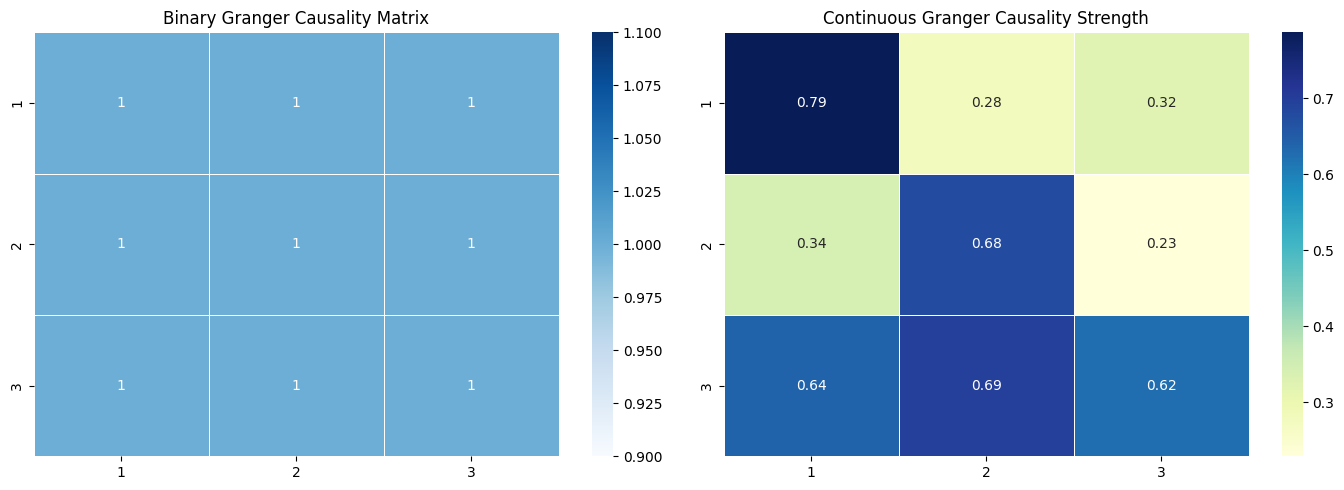

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

save_dir = "/Users/ipa/workspace/Neural-GC/results_three_nodes(iter1500)"

GC = np.load(f"{save_dir}/gc_binary.npy")
GC_strength = np.load(f"{save_dir}/gc_strength.npy")

print("Saved Binary GC matrix:")
print(GC)

print("\nSaved Continuous GC strength matrix:")
print(np.round(GC_strength, 4))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    GC,
    annot=True,
    cmap="Blues",
    fmt=".0f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title("Binary Granger Causality Matrix")

plt.subplot(1, 2, 2)
sns.heatmap(
    GC_strength,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title("Continuous Granger Causality Strength")

plt.tight_layout()
plt.show()

In [11]:
import time
import numpy as np
import torch

# Neural-GC repo 루트 기준
from models.cmlp import cMLP
from models.cmlp import train_model_ista

# ---------------------------
# 1. 데이터 로드
# ---------------------------
path = "/Users/ipa/workspace/Neural-GC/simulated/three_nodes_data.npy"
X = np.load(path).astype(np.float32)
X = torch.tensor(X).unsqueeze(0)   # batch 차원 추가

print("X shape:", X.shape)

# ---------------------------
# 2. 하이퍼파라미터
# ---------------------------
p = X.shape[-1]
lag = 5
hidden = [100]
lam = 0.1
lr = 1e-2
max_iter = 1500
check_every = 100

# ---------------------------
# 3. 모델 생성
# ---------------------------
cmlp = cMLP(
    num_series=p,
    lag=lag,
    hidden=hidden,
    activation='relu'
)

# ---------------------------
# 4. 학습 + 시간 측정
# ---------------------------
start_time = time.time()

loss_history = train_model_ista(
    cmlp,
    X,
    lam=lam,
    lr=lr,
    max_iter=max_iter,
    check_every=check_every,
    verbose=1
)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} min)")

GC = cmlp.GC().cpu().data.numpy()

print("Estimated Granger Causality Matrix:")
print(GC)

X shape: torch.Size([1, 2000, 3])
----------Iter = 100----------
Loss = 3.913425
Variable usage = 100.00%
----------Iter = 200----------
Loss = 3.353297
Variable usage = 100.00%
----------Iter = 300----------
Loss = 2.845351
Variable usage = 100.00%
----------Iter = 400----------
Loss = 2.384012
Variable usage = 100.00%
----------Iter = 500----------
Loss = 1.980701
Variable usage = 100.00%
----------Iter = 600----------
Loss = 1.651685
Variable usage = 100.00%
----------Iter = 700----------
Loss = 1.416323
Variable usage = 100.00%
----------Iter = 800----------
Loss = 1.247133
Variable usage = 100.00%
----------Iter = 900----------
Loss = 1.123134
Variable usage = 100.00%
----------Iter = 1000----------
Loss = 1.039459
Variable usage = 100.00%
----------Iter = 1100----------
Loss = 0.974193
Variable usage = 100.00%
----------Iter = 1200----------
Loss = 0.921414
Variable usage = 100.00%
----------Iter = 1300----------
Loss = 0.889398
Variable usage = 100.00%
----------Iter = 1400-----

In [12]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 저장 폴더
# ---------------------------
save_dir = "/Users/ipa/workspace/Neural-GC/results_three_nodes(iter1500)"
os.makedirs(save_dir, exist_ok=True)

# ---------------------------
# 1) 모델 저장
# ---------------------------
torch.save(cmlp.state_dict(), os.path.join(save_dir, "cmlp_model.pt"))

# ---------------------------
# 1-1) 학습 시간 저장
# ---------------------------
np.save(os.path.join(save_dir, "elapsed_time.npy"), np.array(elapsed_time))

# loss_history가 있으면 같이 저장
if loss_history is not None:
    try:
        loss_history_np = np.array([float(x) for x in loss_history])
        np.save(os.path.join(save_dir, "loss_history.npy"), loss_history_np)
    except:
        pass

# ---------------------------
# 2) Binary GC matrix 추출
# ---------------------------
GC = cmlp.GC().cpu().data.numpy()
np.save(os.path.join(save_dir, "gc_binary.npy"), GC)

# ---------------------------
# 3) Continuous strength matrix 추출
# ---------------------------
def extract_gc_strength(cmlp):
    strengths = []

    for net in cmlp.networks:
        first_conv = None
        for module in net.modules():
            if isinstance(module, torch.nn.Conv1d):
                first_conv = module
                break

        if first_conv is None:
            raise RuntimeError("Conv1d layer를 찾지 못했습니다.")

        w = first_conv.weight.detach().cpu()
        s = torch.norm(w, dim=(0, 2))
        strengths.append(s.numpy())

    strengths = np.stack(strengths, axis=0)
    return strengths

GC_strength = extract_gc_strength(cmlp)
np.save(os.path.join(save_dir, "gc_strength.npy"), GC_strength)

print("Binary GC matrix:")
print(GC)

print("\nContinuous GC strength matrix:")
print(np.round(GC_strength, 4))

print(f"\nSaved training time: {elapsed_time:.2f} sec")

Binary GC matrix:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Continuous GC strength matrix:
[[0.7091 0.2056 0.2403]
 [0.2631 0.7428 0.2659]
 [0.6313 0.7053 0.5891]]

Saved training time: 6.87 sec


Saved Binary GC matrix:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Saved Continuous GC strength matrix:
[[0.7091 0.2056 0.2403]
 [0.2631 0.7428 0.2659]
 [0.6313 0.7053 0.5891]]

Training time: 6.87 sec (0.11 min)


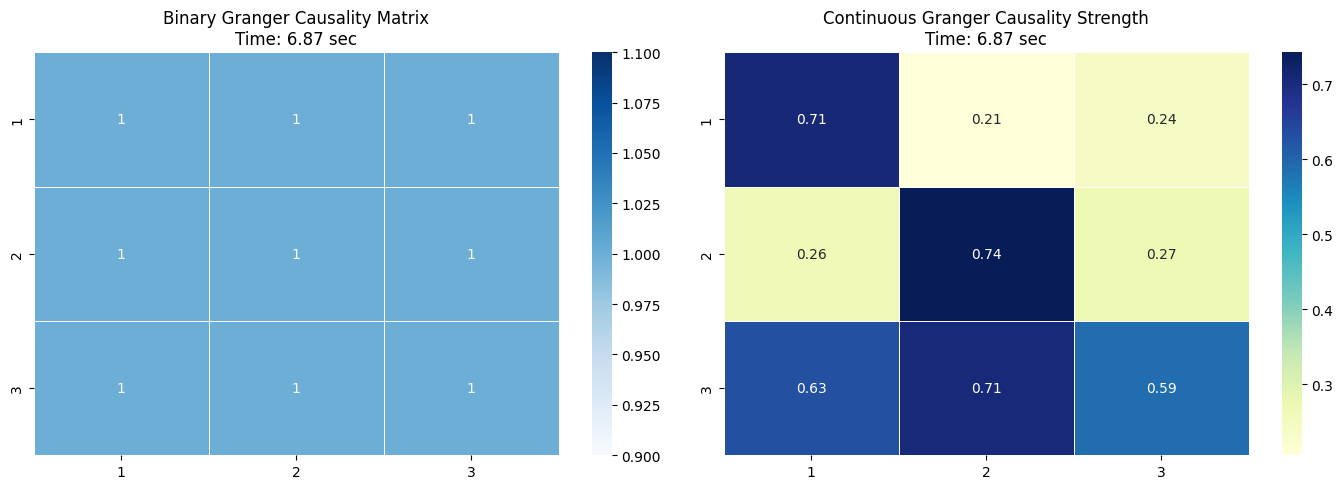

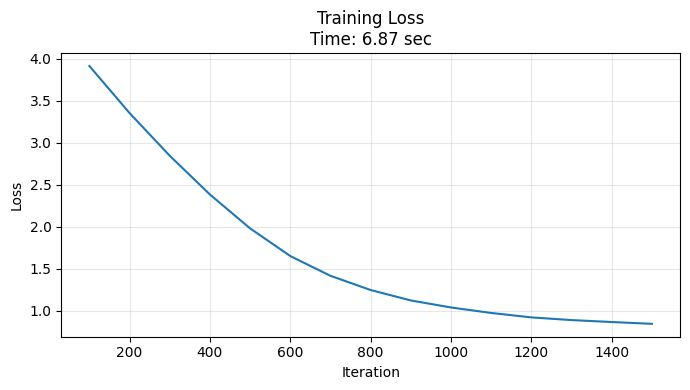

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

save_dir = "/Users/ipa/workspace/Neural-GC/results_three_nodes(iter1500)"

GC = np.load(f"{save_dir}/gc_binary.npy")
GC_strength = np.load(f"{save_dir}/gc_strength.npy")
elapsed_time = np.load(f"{save_dir}/elapsed_time.npy")

print("Saved Binary GC matrix:")
print(GC)

print("\nSaved Continuous GC strength matrix:")
print(np.round(GC_strength, 4))

print(f"\nTraining time: {float(elapsed_time):.2f} sec ({float(elapsed_time)/60:.2f} min)")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    GC,
    annot=True,
    cmap="Blues",
    fmt=".0f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title(f"Binary Granger Causality Matrix\nTime: {float(elapsed_time):.2f} sec")

plt.subplot(1, 2, 2)
sns.heatmap(
    GC_strength,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title(f"Continuous Granger Causality Strength\nTime: {float(elapsed_time):.2f} sec")

plt.tight_layout()
plt.show()

# ---------------------------
# loss plot
# ---------------------------
loss_path = f"{save_dir}/loss_history.npy"

if os.path.exists(loss_path):
    loss_history = np.load(loss_path)

    # iteration 생성 (100, 200, 300, ...)
    check_every = 100
    iterations = np.arange(1, len(loss_history) + 1) * check_every

    plt.figure(figsize=(7, 4))
    plt.plot(iterations, loss_history)   # ✅ marker 제거

    plt.title(f"Training Loss\nTime: {float(elapsed_time):.2f} sec")
    plt.xlabel("Iteration")              # ✅ 변경
    plt.ylabel("Loss")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("loss_history.npy가 저장되지 않았습니다. 현재 train_model_ista가 loss history를 반환하지 않는 버전일 수 있습니다.")

In [1]:
import pickle
import torch
import numpy as np

path = "/Users/ipa/workspace/Neural-GC/simulated/SMAP_train.pkl"

with open(path, "rb") as f:
    train_data = pickle.load(f)

train_data = np.asarray(train_data, dtype=np.float32)
print(train_data.shape)   # 기대: (T, 25)

X = torch.tensor(train_data).unsqueeze(0)
print(X.shape)            # 기대: (1, T, 25)

(135183, 25)
torch.Size([1, 135183, 25])
